# FaIR projections & new plots using
* Bellouin ERFaci prior
* Bellouin ERFari prior
* Model parameters from various CMIP6 models
* SSP 2-4.5
* **climate feeback**: 0.76-1.72

**revisions version**

In [30]:
import pickle
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tol_colors as tc
import matplotlib.colors as mcolors

# script with all the code m
import fair_projections as fp

from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import binned_statistic_2d


In [2]:
import fair

In [3]:
fair.__version__

'2.2.2'

In [4]:
cf_min = 0.76
cf_max = 1.72

In [5]:
fair_out = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/FAIR_proj/"
pickle_path = "/glade/u/home/jnug/work/multi_PPE_data/pickle_jar/"
save_dir = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/figures/"
file_path = "/glade/work/jnug/multi_PPE_data/annual_means/"

fair_data_path = "/glade/work/jnug/multi_PPE_data/FaIR_data/"


### Get the datasets

In [7]:
# all models used in Figs 1-2

models = [
    "UKESM1-0-LL", 
    "MIROC6", 
    "IPSL-CM6A-LR", 
    "CNRM-CM6-1",  
    "CESM2", 
    "GFDL-CM4", 
    # "CNRM-ESM2-1", # r1i1p1f2 (index 2) is the one we have data for; do sep
    # "CanESM5", # r1i1p2f1 (index 0) is the one we have data for; do sep
    "BCC-ESM1", 
    # "MRI-ESM2-0", # r1i1p1f1 (index 0) is the one we have data for; do sep
    # "GISS-E2-1-G", # r1i1p1f1 (index 1) is the one we have data for; do sep
    "MPI-ESM-1-2-HAM", 
    "HadGEM3-GC31-LL", 
    "NorESM2-LM",
    "NorESM2-MM"
]

print(len(models))


11


In [10]:
import importlib
importlib.reload(fp)

<module 'fair_projections' from '/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/fair_projections.py'>

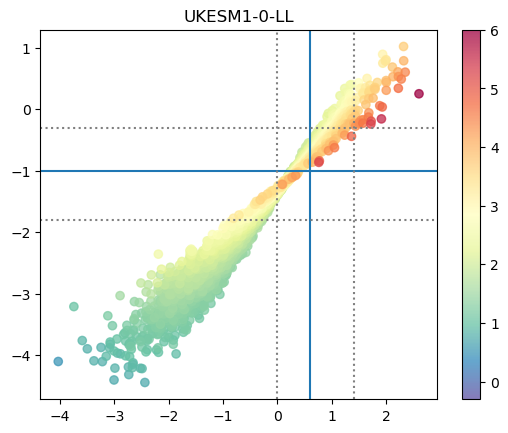

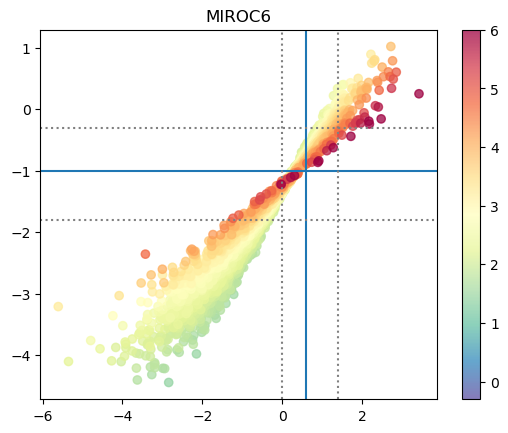

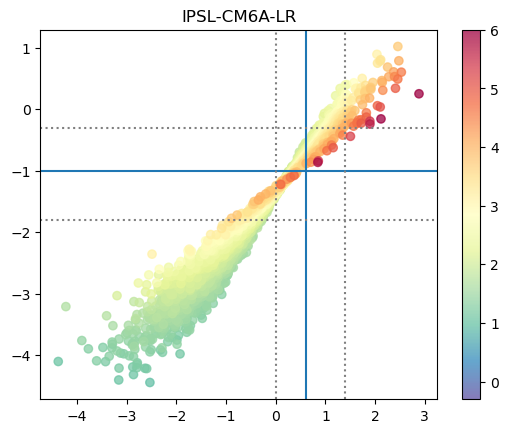

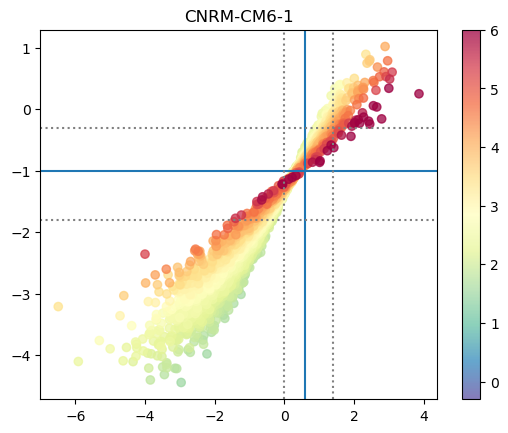

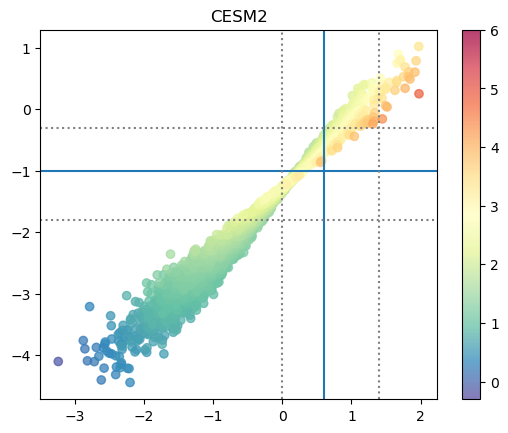

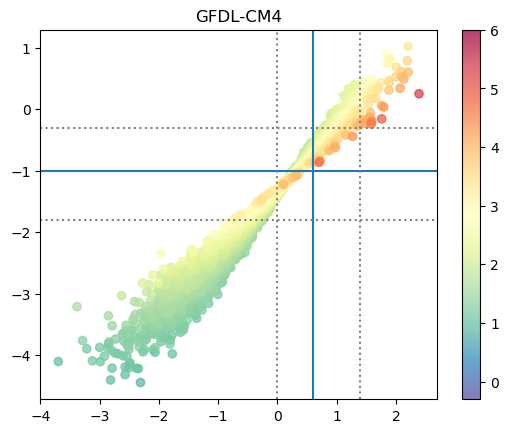

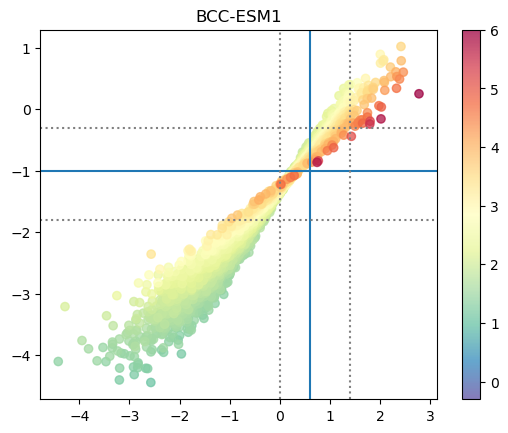

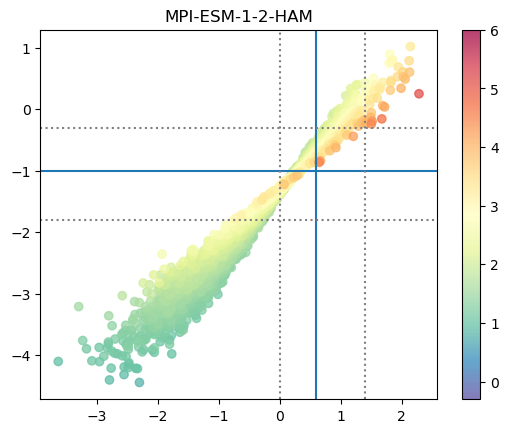

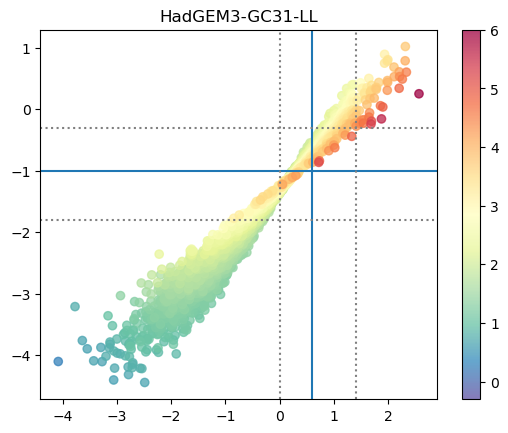

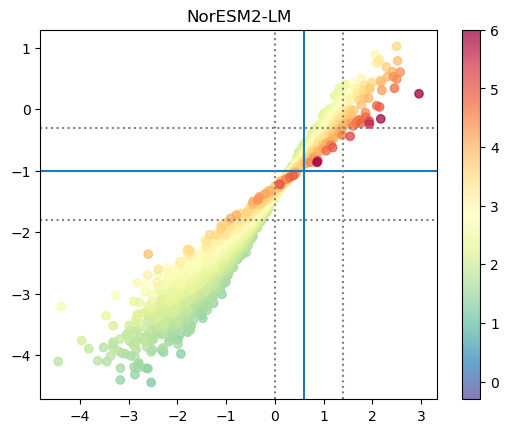

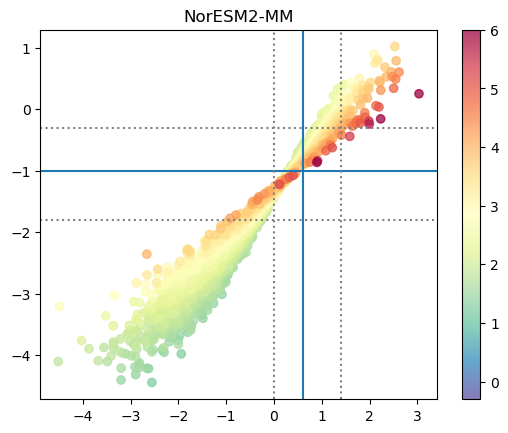

In [11]:
# calc for the models with single ensemble
ds_dict = {}

for model in models:
    ds_dict[model] = fp.get_save_temp_projections(model, cf_min=cf_min, cf_max=cf_max, ssp=245, fair_out=fair_out)


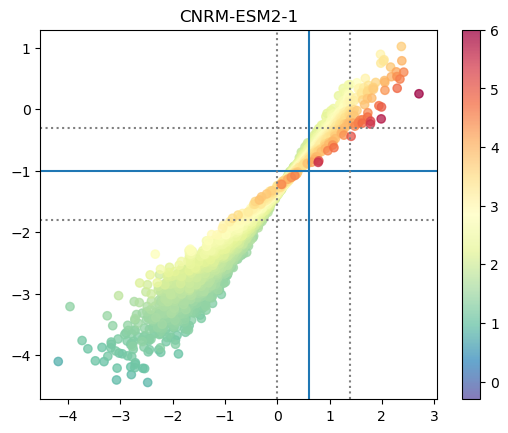

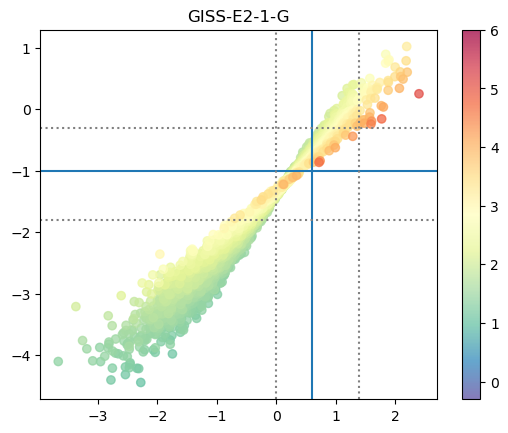

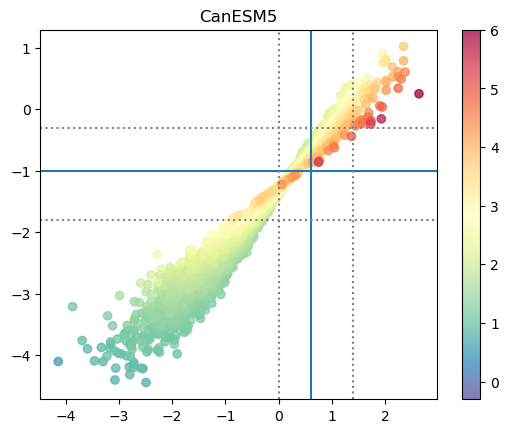

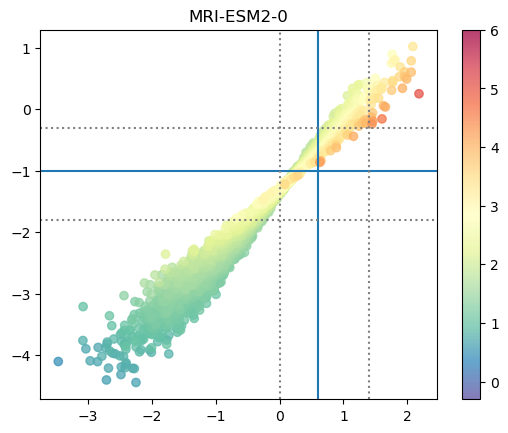

In [12]:
# calc for the others to get the specific realizations/ensemble members

ds_dict["CNRM-ESM2-1__2"] = fp.get_save_temp_projections("CNRM-ESM2-1", cf_min=cf_min, cf_max=cf_max, ssp=245, index=2, fair_out=fair_out)
ds_dict["GISS-E2-1-G__1"] = fp.get_save_temp_projections("GISS-E2-1-G", cf_min=cf_min, cf_max=cf_max, ssp=245, index=1, fair_out=fair_out)
ds_dict["CanESM5__0"] = fp.get_save_temp_projections("CanESM5", cf_min=cf_min, cf_max=cf_max, ssp=245, index=0, fair_out=fair_out)
ds_dict["MRI-ESM2-0__0"] = fp.get_save_temp_projections("MRI-ESM2-0", cf_min=cf_min, cf_max=cf_max, ssp=245, index=0, fair_out=fair_out)


In [13]:
ds_all = xr.concat(list(ds_dict.values()), dim="ensemble")
ds_all.attrs["model"] = "aggregate of all"
ds_all.to_netcdf(fair_out + f"CMIP6_aggregate__SSP245__WCRP_prior__temp_projections.nc")


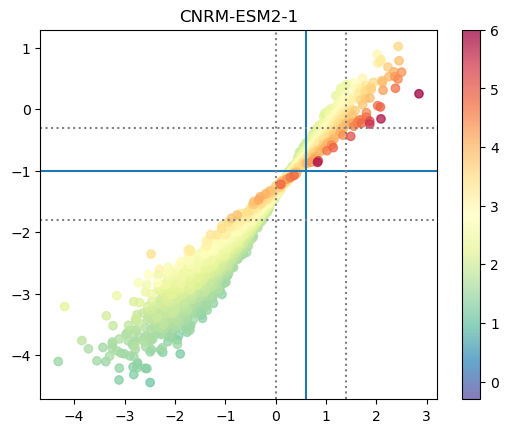

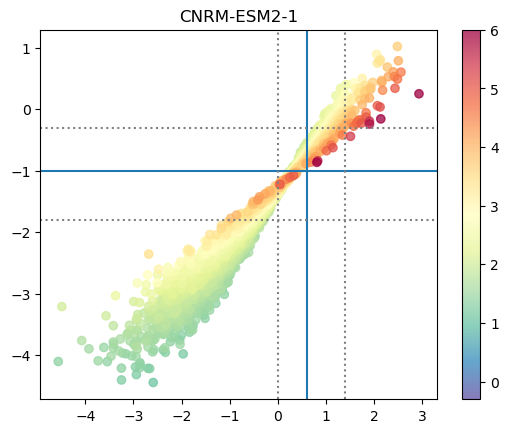

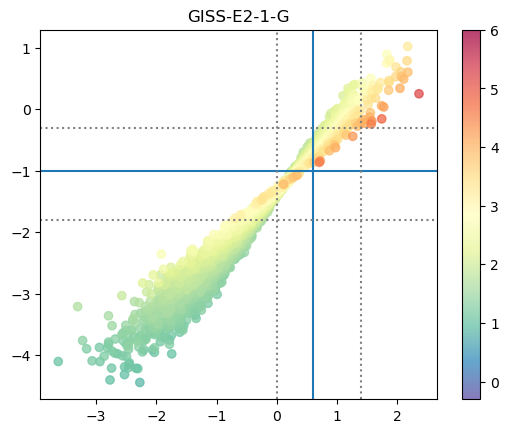

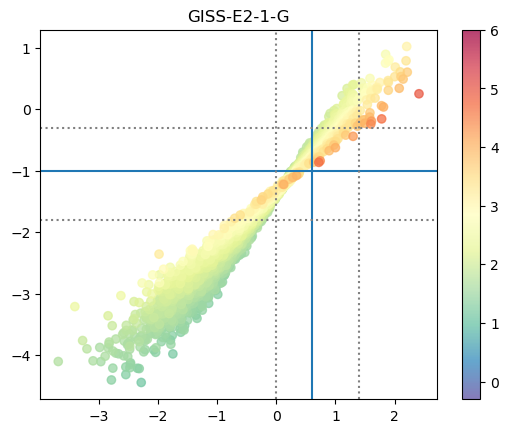

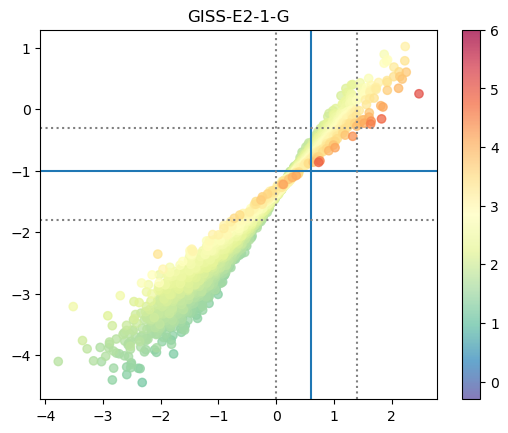

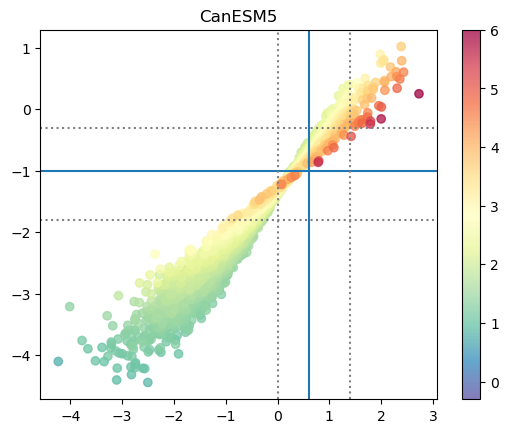

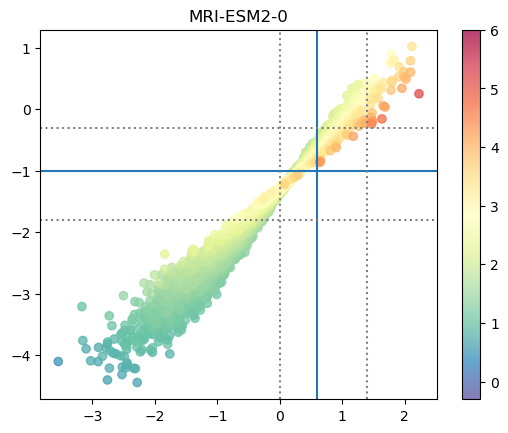

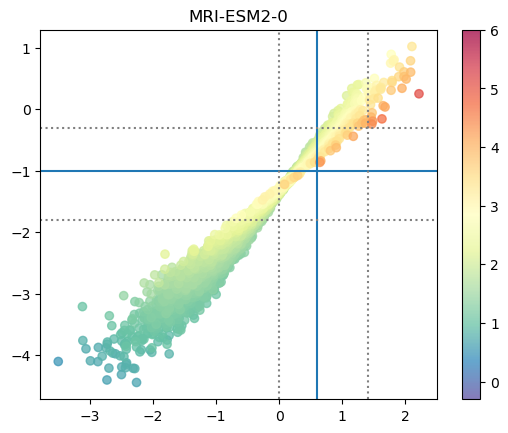

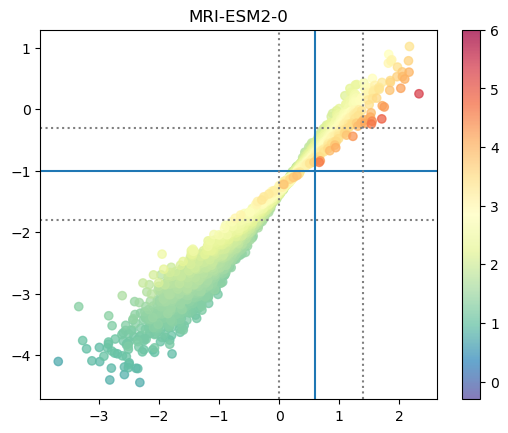

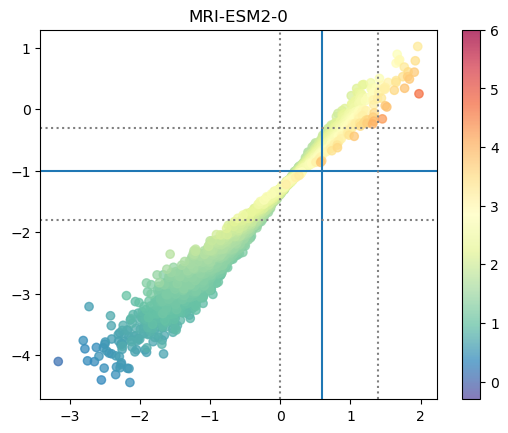

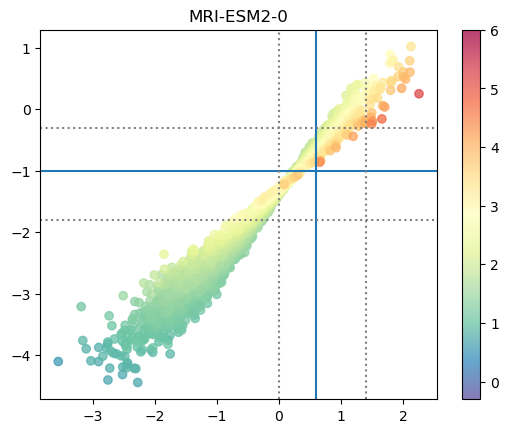

In [14]:
# calc for all other realizations of the models we have
ds_dict = {}

ds_dict["CNRM-ESM2-1__0"] = fp.get_save_temp_projections("CNRM-ESM2-1", cf_min=cf_min, cf_max=cf_max, ssp=245, index=0, fair_out=fair_out)
ds_dict["CNRM-ESM2-1__1"] = fp.get_save_temp_projections("CNRM-ESM2-1", cf_min=cf_min, cf_max=cf_max, ssp=245, index=1, fair_out=fair_out)

ds_dict["GISS-E2-1-G__0"] = fp.get_save_temp_projections("GISS-E2-1-G", cf_min=cf_min, cf_max=cf_max, ssp=245, index=0, fair_out=fair_out)
ds_dict["GISS-E2-1-G__2"] = fp.get_save_temp_projections("GISS-E2-1-G", cf_min=cf_min, cf_max=cf_max, ssp=245, index=2, fair_out=fair_out)
ds_dict["GISS-E2-1-G__3"] = fp.get_save_temp_projections("GISS-E2-1-G", cf_min=cf_min, cf_max=cf_max, ssp=245, index=3, fair_out=fair_out)

ds_dict["CanESM5__1"] = fp.get_save_temp_projections("CanESM5", cf_min=cf_min, cf_max=cf_max, ssp=245, index=1, fair_out=fair_out)

ds_dict["MRI-ESM2-0__1"] = fp.get_save_temp_projections("MRI-ESM2-0", cf_min=cf_min, cf_max=cf_max, ssp=245, index=1, fair_out=fair_out)
ds_dict["MRI-ESM2-0__2"] = fp.get_save_temp_projections("MRI-ESM2-0", cf_min=cf_min, cf_max=cf_max, ssp=245, index=2, fair_out=fair_out)
ds_dict["MRI-ESM2-0__3"] = fp.get_save_temp_projections("MRI-ESM2-0", cf_min=cf_min, cf_max=cf_max, ssp=245, index=3, fair_out=fair_out)
ds_dict["MRI-ESM2-0__4"] = fp.get_save_temp_projections("MRI-ESM2-0", cf_min=cf_min, cf_max=cf_max, ssp=245, index=4, fair_out=fair_out)
ds_dict["MRI-ESM2-0__5"] = fp.get_save_temp_projections("MRI-ESM2-0", cf_min=cf_min, cf_max=cf_max, ssp=245, index=5, fair_out=fair_out)


In [15]:
ds_all = xr.concat(list(ds_dict.values()), dim="ensemble")
ds_all.attrs["model"] = "aggregate of all (bonus)"
ds_all.to_netcdf(fair_out + f"CMIP6_aggregate_bonus__SSP245__WCRP_prior__temp_projections.nc")


### New plots


In [6]:
# 5-95% range from Sherwood et al. 2020
# ecs_range = [2.3, 4.7]

# Forster et al. 2021; use this one (pg. 926)
# "very likely" range - 90-100%
ecs_range = [2, 5]

# from Forster et al. 2021; TOA energy imbalance change for 2018-2006
# (table 7.1, pg. 938)
# "very likely" range - 90%-100%
toa_imb_range = [0.52, 1.06]


In [7]:
# UNconstrained

# add in the "bonus" ones - these are from other realizations/ensn of the models shown in Figs1-2
ds_all_uc1 = xr.open_dataset(fair_out + f"CMIP6_aggregate__SSP245__WCRP_prior__temp_projections.nc")
ds_all_uc2 = xr.open_dataset(fair_out + f"CMIP6_aggregate_bonus__SSP245__WCRP_prior__temp_projections.nc")

ds_all_uc = xr.concat([ds_all_uc1, ds_all_uc2], dim="ensemble")
ds_all_uc = ds_all_uc.assign_coords({"ensemble": np.arange(len(ds_all_uc.ensemble))})


In [8]:
# TOA energy imbalance change for 2018-2006
imb_20062018 = ds_all_uc.TOA_energy_imbalance.sel(year=2018) - ds_all_uc.TOA_energy_imbalance.sel(year=2006)


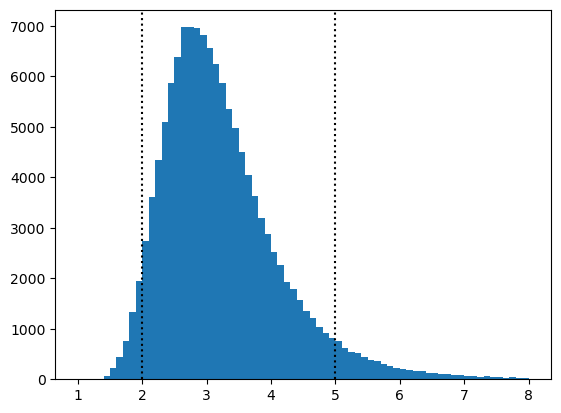

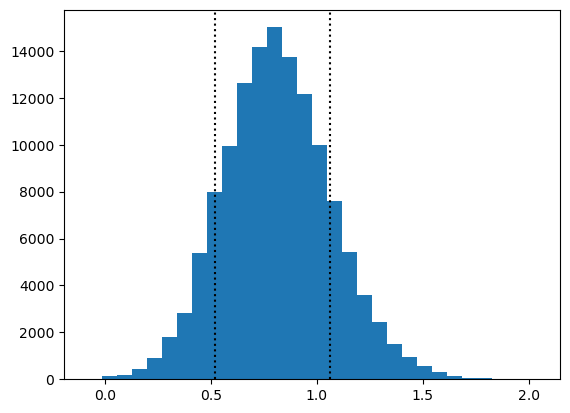

In [9]:
# quick check out the priors

bins = np.arange(1.0, 8.1, 0.1)
plt.hist(ds_all_uc.ECS, bins=bins)
plt.axvline(ecs_range[0], color="k", ls=":")
plt.axvline(ecs_range[1], color="k", ls=":")
plt.show()


plt.hist(imb_20062018, bins=30)
plt.axvline(toa_imb_range[0], color="k", ls=":")
plt.axvline(toa_imb_range[1], color="k", ls=":")
plt.show()



In [10]:
# before you do anything - apply climate constraints (ECS & TOA energy imbalance)
ds_all = ds_all_uc.where((ds_all_uc.ECS <= ecs_range[1]) & (ds_all_uc.ECS >= ecs_range[0]) & (imb_20062018 >= toa_imb_range[0]) & (imb_20062018 <= toa_imb_range[1]), drop=True)
ERFaer = ds_all["ERFaci"] + ds_all["ERFari"]
ERFaci = ds_all["ERFaci"]


In [11]:
def ar6_dt_hist(temps):
    """
    T(2011-2020) = T(1900-1850) + [0.95, 1.20]
    """
    temp_baseline = temps.sel(year=slice(1850, 1900)).mean('year')
    temp_recent = temps.sel(year=slice(2011, 2020)).mean('year')
    temp_diff = temp_recent - temp_baseline
    return temp_diff


In [12]:
def dt_future_2050_1850(temps):
    """
    T(2050) - T(1850)
    """
    temp_diff = temps.sel(year=2050) - temps.sel(year=1850)
    return temp_diff


In [13]:
def dt_future_2100_1850(temps):
    """
    T(2100) - T(1850)
    """
    temp_diff = temps.sel(year=2100) - temps.sel(year=1850)
    return temp_diff


In [14]:
def dt_future2_2100_1850(temps):
    """
    T(2100) - T(1850-1900)
    """
    temp_diff = temps.sel(year=2100) - temps.sel(year=slice(1850, 1900)).mean(dim="year")
    return temp_diff


In [15]:
# get AR6 temperature 90% CI (from the 1sigma/68%)
lower = 0.95
upper = 1.2

mu = (lower + upper) / 2 
sigma = ( (upper - mu) / 1 )  # z=1 for 68% confidence.

ar6_ci90 = stats.norm.interval(0.9, loc=mu, scale=sigma)
print(ar6_ci90)

(0.8693932966310658, 1.280606703368934)


In [16]:
dt_hist = ar6_dt_hist(ds_all["temps"])
dt_future_2050 = dt_future_2050_1850(ds_all["temps"])
dt_future_2100 = dt_future_2100_1850(ds_all["temps"])


In [17]:
# historical temperature record - T(2011-2020) - T(1900-1850)
temp_record = dt_hist.values

In [18]:
# ERFaci (big prior)
erfaci_scatter = ERFaci.values

In [19]:
# 2050 - 1850
future_temp = dt_future_2050.values

#### Hists - probability of exceeding +2C

In [20]:
# from Bellouin paper - 90% CI
wcrp_erfaci = [-2.65, -0.07]

# MM-PPE range - 90% CI (using hemispheric Nd)
with open(pickle_path + "GP_regression_rev/MM-PPE_ERFaci_CI_final.pickle", "rb") as handle:
    mmppe_erfaci = pickle.load(handle)["90%"]
print(mmppe_erfaci)


[-2.105743266535622, -0.7093990168730874]


In [47]:
# check stats for these too, but don't bother with plots
# (might ref in text)
# mmppe_erfaci = [-2.727811407080017, -0.23995491117060364] # no tolerance
# mmppe_erfaci = [-2.6402279923250136, -1.0380186367063453] # dnd hem
# mmppe_erfaci = [-2.3196920707180713, -0.7624580570693287] # hem constr, pd-pi input/predict


In [21]:
temp_constr = (temp_record <= ar6_ci90[1]) & (temp_record >= ar6_ci90[0])
wcrp_erfaci_constr = (erfaci_scatter <= wcrp_erfaci[1]) & (erfaci_scatter >= wcrp_erfaci[0])
mmppe_erfaci_constr = (erfaci_scatter <= mmppe_erfaci[1]) & (erfaci_scatter >= mmppe_erfaci[0])


3.01446081618745 3.56100684774218 4.095892312621915
4.9997663832601695 4.983294743011098


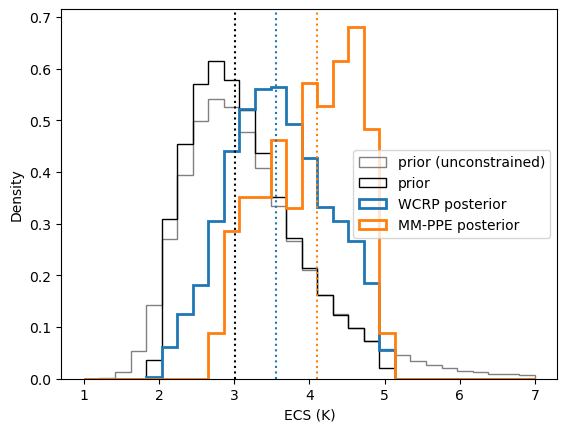

In [22]:
# does ECS change?

ecs_all = ds_all.ECS.values
ecs_wcrp = ecs_all[wcrp_erfaci_constr & temp_constr]
ecs_mmppe = ecs_all[mmppe_erfaci_constr & temp_constr]

ebins = np.linspace(1, 7, 30)
plt.hist(ds_all_uc.ECS, histtype="step", bins=ebins, density=True, color="gray", label="prior (unconstrained)")
plt.hist(ecs_all, histtype="step", bins=ebins, density=True, color="k", label="prior")
plt.hist(ecs_wcrp, histtype="step", bins=ebins, density=True, label="WCRP posterior", lw=2)
plt.hist(ecs_mmppe, histtype="step", bins=ebins, density=True, label="MM-PPE posterior", lw=2)

plt.axvline(np.median(ecs_wcrp), color="C0", ls=":")
plt.axvline(np.median(ecs_mmppe), color="C1", ls=":")
plt.axvline(np.median(ecs_all), color="k", ls=":")

print(np.median(ecs_all), np.median(ecs_wcrp), np.median(ecs_mmppe))
print(ecs_wcrp.max(), ecs_mmppe.max())
plt.xlabel("ECS (K)")
plt.ylabel("Density")
plt.legend()

plt.show()


In [23]:
wcrp_proj = future_temp[wcrp_erfaci_constr & temp_constr]
mmppe_proj = future_temp[mmppe_erfaci_constr & temp_constr]

In [24]:
# make arrays for 1850-2010 projections
temp_proj_ts = ds_all["temps"].sel(year=slice(1850, 2100)).values
years = ds_all["temps"].sel(year=slice(1850, 2100)).year.values

# limit to the constrained ones 
temp_proj_ts_wcrp = temp_proj_ts[wcrp_erfaci_constr & temp_constr]
temp_proj_ts_mmppe = temp_proj_ts[mmppe_erfaci_constr & temp_constr]


##### Final GP reg values / main analysis

In [25]:
# probability of exceeding 2 C by 2050  - ECS + imb
# note - does not change if 1850-1900 baseline is used instead of 1850
print("WCRP:", len(wcrp_proj[wcrp_proj >= 2])/len(wcrp_proj))
print("MMPPE:", len(mmppe_proj[mmppe_proj >= 2])/len(mmppe_proj))
print(len(mmppe_proj))


WCRP: 0.7777163395078794
MMPPE: 0.9818181818181818
220


In [26]:
# when the median exceeds 2C - ECS + imb

year_exceed_wcrp = years[np.where(np.median(temp_proj_ts_wcrp, axis=0) > 2)[0][0]]
year_exceed_mmppe = years[np.where(np.median(temp_proj_ts_mmppe, axis=0) > 2)[0][0]]
print(year_exceed_wcrp, year_exceed_mmppe)

2046 2043


##### Sensitiivty tests

In [46]:
# probability of exceeding 2 C by 2050  - ECS + imb
# dnd hem
print("WCRP:", len(wcrp_proj[wcrp_proj >= 2])/len(wcrp_proj))
print("MMPPE:", len(mmppe_proj[mmppe_proj >= 2])/len(mmppe_proj))
print(len(mmppe_proj))

# when the median exceeds 2C - ECS + imb
year_exceed_wcrp = years[np.where(np.median(temp_proj_ts_wcrp, axis=0) > 2)[0][0]]
year_exceed_mmppe = years[np.where(np.median(temp_proj_ts_mmppe, axis=0) > 2)[0][0]]
print(year_exceed_wcrp, year_exceed_mmppe)


WCRP: 0.7777163395078794
MMPPE: 1.0
4
2046 2041


#### Final plot

In [27]:
# custom discrete rainbow colormap
# from tol_colors rainbow_discrete
temp_colors = [
    "#d9cce3",
    "#caaccb",
    "#ba8db4",
    "#ab6f9e",
    "#994f88",
    "#882e72",
    "#514a91",
    "#1866b0",
    "#437dbf",
    "#6195cf",
    "#7bafde",
    "#41967d",
    "#4eb265",
    "#90c987",
    "#cae0ab",
    "#e1e881",
    "#f7f057",
    "#f7d94d",
    "#f7cb46",
    "#f4a735",
    "#ef8026",
    "#e65518",
    "#dc050d",
    "#a5180e",
    "#72190e",
]
temp_cmap = mcolors.ListedColormap(temp_colors)
temp_cmap.set_over("#42150b")


In [28]:
vmin = 0
vmax = 3
sort_temp_scatters = True
temp_alpha = 0.6
legsize = 8
labsize = 11
fsize = 12
tsize = 13
figsize = (13, 10)
wcrp_col = "#66CCEE"
mmppe_col = "#997700"
single_temp_cbar = True


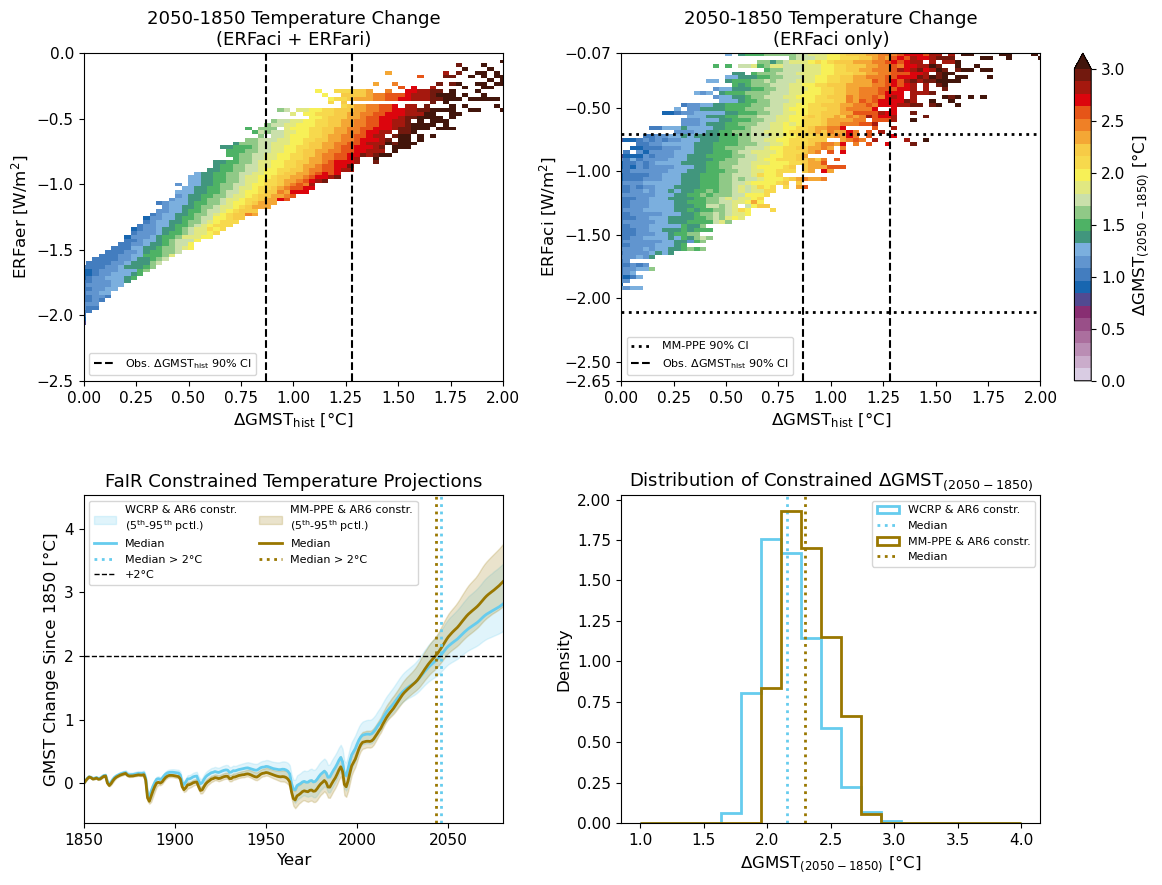

In [31]:
fig = plt.figure(figsize=figsize)

if not single_temp_cbar:
    gs = GridSpec(2, 2, hspace=0.25)
    ax_aer = fig.add_subplot(gs[0, 0])
    ax_aci = fig.add_subplot(gs[0, 1])
    ax_ts = fig.add_subplot(gs[1, 0])
    ax_hist = fig.add_subplot(gs[1, 1])

else:
    # add a dummy subplot to fill out the middle so the colorbar can be closer to the plots
    gs = GridSpec(2, 4, width_ratios=[1.25, 0.15, 1.25, 0.05], wspace=0.15, hspace=0.35)
    ax_cbar = fig.add_subplot(gs[0, 3])
    ax_aer = fig.add_subplot(gs[0, 0])
    ax_aci = fig.add_subplot(gs[0, 2])
    ax_ts = fig.add_subplot(gs[1, 0])
    ax_hist = fig.add_subplot(gs[1, 2])

    # gs = GridSpec(2, 3, width_ratios=[1.25, 1.25, 0.05], wspace=0.4, hspace=0.25)
    # ax_cbar = fig.add_subplot(gs[0, 2])
    # ax_aer = fig.add_subplot(gs[0, 0])
    # ax_aci = fig.add_subplot(gs[0, 1])
    # ax_ts = fig.add_subplot(gs[1, 0])
    # ax_hist = fig.add_subplot(gs[1, 1])



####### 2D histograms #######
bins = 150
aer_result = binned_statistic_2d(dt_hist, ERFaer, dt_future_2050, statistic="mean", bins=bins)
aci_result = binned_statistic_2d(dt_hist, ERFaci, dt_future_2050, statistic="mean", bins=bins)
Xaer, Yaer = np.meshgrid(aer_result.x_edge, aer_result.y_edge)
Xaci, Yaci = np.meshgrid(aci_result.x_edge, aci_result.y_edge)

# ERFaer
pcm = ax_aer.pcolormesh(Xaer, Yaer, aer_result.statistic.T, cmap=temp_cmap, vmin=vmin, vmax=vmax)
ax_aer.set_ylabel("ERFaer [W/m$^2$]", fontsize=fsize)
ax_aer.set_ylim(-2.5, 0)
ax_aer.set_title("2050-1850 Temperature Change\n(ERFaci + ERFari)", fontsize=tsize)

# # ERFaci 
pcm = ax_aci.pcolormesh(Xaci, Yaci, aci_result.statistic.T, cmap=temp_cmap, vmin=vmin, vmax=vmax)
ax_aci.set_ylabel("ERFaci [W/m$^2$]", fontsize=fsize)
ax_aci.set_ylim(wcrp_erfaci)
ax_aci.set_title("2050-1850 Temperature Change\n(ERFaci only)", fontsize=tsize)
aci_ticks = ax_aci.get_yticks()
new_aci_ticks = [wcrp_erfaci[0], *aci_ticks[1:-1], wcrp_erfaci[1]]
ax_aci.set_yticks(new_aci_ticks)
ax_aci.axhline(mmppe_erfaci[0], color="k", ls=":", label="MM-PPE 90% CI", lw=2)
ax_aci.axhline(mmppe_erfaci[1], color="k", ls=":", lw=2)


# same for both 
for ax in [ax_aer, ax_aci]:
    ax.axvline(ar6_ci90[0], color="k", ls="--", label=r"Obs. $\Delta$$\mathrm{GMST_{hist}}$ 90% CI")
    ax.axvline(ar6_ci90[1], color="k", ls="--")
    ax.legend(fontsize=legsize, loc="lower left")
    ax.set_xlabel(r"$\Delta$$\mathrm{GMST_{hist}}$ [°C]", fontsize=fsize)
    ax.set_xlim(0, 2)
    # ax.set_xticks(np.arange(0, 2.25, 0.5))
    ax.tick_params(axis="both", labelsize=labsize)
    if not single_temp_cbar:
        cbar = plt.colorbar(pcm, ax=ax, extend="max", orientation="vertical")
        cbar.ax.tick_params(labelsize=labsize)
        cbar.set_label(r"$\Delta$$\mathrm{GMST_{(2050-1850)}}$ [°C]", fontsize=fsize-2)

# single colorbar
if single_temp_cbar:
    cbar = plt.colorbar(pcm, cax=ax_cbar, extend="max", orientation="vertical")
    cbar.ax.tick_params(labelsize=labsize)
    cbar.set_label(r"$\Delta$$\mathrm{GMST_{(2050-1850)}}$ [°C]", fontsize=fsize)


####### time series #######
# shade 5th-95th percentiles & line for median
ax_ts.fill_between(years, np.percentile(temp_proj_ts_wcrp, 5, axis=0), np.percentile(temp_proj_ts_wcrp, 95, axis=0), color=wcrp_col, alpha=0.2,# zorder=0)
                label="WCRP & AR6 constr.\n" + r"(5$^{\mathrm{th}}$-95$^{\mathrm{th}}$ pctl.)", zorder=0) 
ax_ts.fill_between(years, np.percentile(temp_proj_ts_mmppe, 5, axis=0), np.percentile(temp_proj_ts_mmppe, 95, axis=0), color=mmppe_col, alpha=0.2,# zorder=0)
                label="MM-PPE & AR6 constr.\n" + r"(5$^{\mathrm{th}}$-95$^{\mathrm{th}}$ pctl.)", zorder=0)
ax_ts.plot(years, np.median(temp_proj_ts_wcrp, axis=0), label="Median",#WCRP and AR6 constraints (median)", 
        linewidth=2, color=wcrp_col)
ax_ts.plot(years, np.median(temp_proj_ts_mmppe, axis=0), label="Median", #MM-PPE and AR6 constraints (median)", 
        linewidth=2, color=mmppe_col)

# axes
ax_ts.set_title("FaIR Constrained Temperature Projections", fontsize=tsize)
ax_ts.set_xlim(1850, 2080)
ax_ts.set_ylabel("GMST Change Since 1850 [°C]", fontsize=fsize)
ax_ts.axhline(2, color="k", ls="--", lw=1, label="+2°C")
ax_ts.axvline(year_exceed_wcrp, color=wcrp_col, ls=":", label="Median > 2°C", lw=2)#WCRP median > 2°C", lw=2)
ax_ts.axvline(year_exceed_mmppe, color=mmppe_col, ls=":", label="Median > 2°C", lw=2)#label="MM-PPE median > 2°C", lw=2)
ax_ts.tick_params(axis="both", labelsize=labsize)
ax_ts.set_xlabel("Year", fontsize=fsize)

# legend
handles, labels = ax_ts.get_legend_handles_labels()
# new_order = [0, 2, 5, 1, 3, 6, 4]
new_order = [0, 2, 5, 4, 1, 3, 6]
new_labels = [labels[x] for x in new_order]
new_handles = [handles[x] for x in new_order]
ax_ts.legend(handles=new_handles, labels=new_labels, fontsize=legsize, ncol=2)


####### histograms #######
bins = np.linspace(1, 4, 20)

ax_hist.hist(wcrp_proj, histtype="step", density=True, bins=bins, label="WCRP & AR6 constr.", linewidth=2, color=wcrp_col)
ax_hist.axvline(np.median(wcrp_proj), color=wcrp_col, ls=":", lw=2, label="Median")
ax_hist.hist(mmppe_proj, histtype="step", density=True, bins=bins, label="MM-PPE & AR6 constr.", linewidth=2, color=mmppe_col)
ax_hist.axvline(np.median(mmppe_proj), color=mmppe_col, ls=":", lw=2, label="Median")
ax_hist.legend(loc="upper right", fontsize=legsize)
ax_hist.set_title(r"Distribution of Constrained $\Delta$$\mathrm{GMST_{(2050-1850)}}$", fontsize=tsize)
ax_hist.set_xlabel(r"$\Delta$$\mathrm{GMST_{(2050-1850)}}$ [°C]", fontsize=fsize)
ax_hist.set_ylabel("Density", fontsize=fsize)
ax_hist.tick_params(axis="both", labelsize=labsize)



plt.savefig(save_dir + "FigS5_complete_with_ts_panel_SSP245__ndpipd_2dhist.png", dpi=300, bbox_inches="tight")

plt.show()

